1. Create the Dataset
○Define input (X) and output (y) arrays for all 4 XOR combinations.


In [ ]:
import numpy as np


X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("Inputs (X):\n", X)
print("\nOutputs (y):\n", y)

Inputs (X):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Outputs (y):
 [[0.]
 [1.]
 [1.]
 [0.]]


2. Build an MLP
○Input layer: size 2 (for the two inputs).
○Hidden layer: at least 2 neurons with ReLU or Tanh activation.
○Output layer: 1 neuron with sigmoid activation for binary classification.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Dense(4, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

Compile the Model / Define Loss and Optimizer

Use Binary Cross-Entropy loss

Use an optimizer of your choic


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")
print("Loss function:", model.loss)
print("Optimizer:", model.optimizer.__class__.__name__)
print("Learning rate:", model.optimizer.learning_rate.numpy())

Model compiled successfully
Loss function: binary_crossentropy
Optimizer: Adam
Learning rate: 0.05


Train the model on the XOR dataset

Experiment with epochs, learning rate, and number of neurons to improve
performance


In [ ]:
history = model.fit(
    X, y,
    epochs=500,
    verbose=1
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step - accuracy: 0.7500 - loss: 0.7320
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.7097
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2500 - loss: 0.7014
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.6948
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7500 - loss: 0.6885
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7500 - loss: 0.6839
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.6813
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.6794
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7500 - loss: 0.6766
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.6721
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7500 - loss: 0.6660
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - l

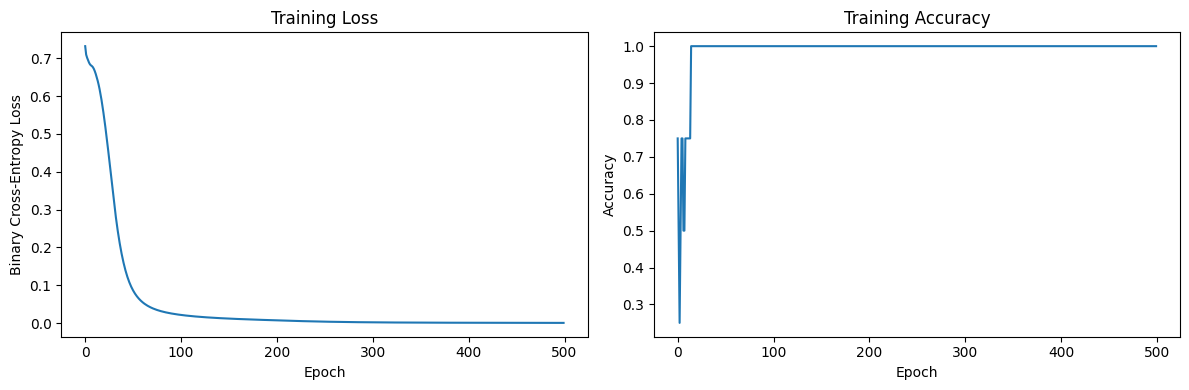

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'])
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Binary Cross-Entropy Loss')

ax[1].plot(history.history['accuracy'])
ax[1].set_title('Training Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

 Evaluate the Model
○Predict outputs for all 4 input combinations.


In [ ]:
predictions = model.predict(X)

print("Input Combinations:\n", X)
print("\nRaw Predictions (probabilities):\n", predictions)
print("\nRounded Predictions:\n", predictions.round().astype(int))
print("\nActual XOR Outputs:\n", y.astype(int))

correct = np.sum(predictions.round() == y)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Input Combinations:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Raw Predictions (probabilities):
 [[5.0952018e-04]
 [9.9951410e-01]
 [9.9960923e-01]
 [5.8603234e-04]]

Rounded Predictions:
 [[0]
 [1]
 [1]
 [0]]

Actual XOR Outputs:
 [[0]
 [1]
 [1]
 [0]]


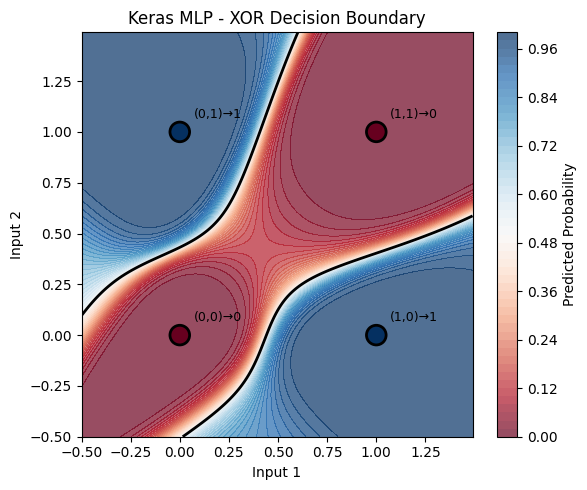

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                          np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, preds, levels=50, cmap='RdBu', alpha=0.7)
    plt.colorbar(label='Predicted Probability')
    plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu',
                edgecolors='black', s=200, linewidths=2)

    for i, (x0, x1) in enumerate(X):
        plt.annotate(f'({int(x0)},{int(x1)})→{int(y[i][0])}',
                      (x0, x1), textcoords="offset points",
                      xytext=(10, 10), fontsize=9)

    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model, X, y, title="Keras MLP - XOR Decision Boundary")

TensorFlow low-level implementation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

X_tf = tf.constant([[0,0],[0,1],[1,0],[1,1]], dtype=tf.float32)
y_tf = tf.constant([[0],[1],[1],[0]], dtype=tf.float32)

print("Inputs:\n", X_tf.numpy())
print("\nOutputs:\n", y_tf.numpy())

Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Outputs:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [ ]:
# Hidden layer: 2 inputs -> 4 neurons
W1 = tf.Variable(tf.random.normal([2, 4], stddev=1.0, seed=42), name="W1")
b1 = tf.Variable(tf.zeros([4]), name="b1")

# Output layer: 4 neurons -> 1 output
W2 = tf.Variable(tf.random.normal([4, 1], stddev=1.0, seed=42), name="W2")
b2 = tf.Variable(tf.zeros([1]), name="b2")

def mlp_forward(X):
    hidden = tf.tanh(tf.matmul(X, W1) + b1)      # hidden layer, tanh activation
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)  # output layer, sigmoid
    return output

# Quick sanity check with untrained weights
print("Untrained output:\n", mlp_forward(X_tf).numpy())

Untrained output:
 [[0.5       ]
 [0.33996162]
 [0.4632813 ]
 [0.36913124]]


In [ ]:
def binary_crossentropy_loss(y_true, y_pred):
    epsilon = 1e-7  # avoid log(0)
    y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) +
                            (1 - y_true) * tf.math.log(1 - y_pred))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

# Quick check
loss_val = binary_crossentropy_loss(y_tf, mlp_forward(X_tf))
print("Initial loss:", loss_val.numpy())


Initial loss: 0.750537


In [ ]:
epochs = 500
loss_history = []
accuracy_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = mlp_forward(X_tf)
        loss = binary_crossentropy_loss(y_tf, y_pred)


    gradients = tape.gradient(loss, [W1, b1, W2, b2])


    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))


    loss_history.append(loss.numpy())
    preds_binary = tf.round(y_pred)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds_binary, y_tf), tf.float32))
    accuracy_history.append(acc.numpy())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.numpy():.4f} | Accuracy: {acc.numpy():.4f}")

print(f"\nFinal Loss: {loss_history[-1]:.4f}")
print(f"Final Accuracy: {accuracy_history[-1]:.4f}")

Epoch   0 | Loss: 0.7145 | Accuracy: 0.5000
Epoch  50 | Loss: 0.1495 | Accuracy: 1.0000
Epoch 100 | Loss: 0.0165 | Accuracy: 1.0000
Epoch 150 | Loss: 0.0077 | Accuracy: 1.0000
Epoch 200 | Loss: 0.0047 | Accuracy: 1.0000
Epoch 250 | Loss: 0.0033 | Accuracy: 1.0000
Epoch 300 | Loss: 0.0024 | Accuracy: 1.0000
Epoch 350 | Loss: 0.0019 | Accuracy: 1.0000
Epoch 400 | Loss: 0.0015 | Accuracy: 1.0000
Epoch 450 | Loss: 0.0013 | Accuracy: 1.0000

Final Loss: 0.0011
Final Accuracy: 1.0000


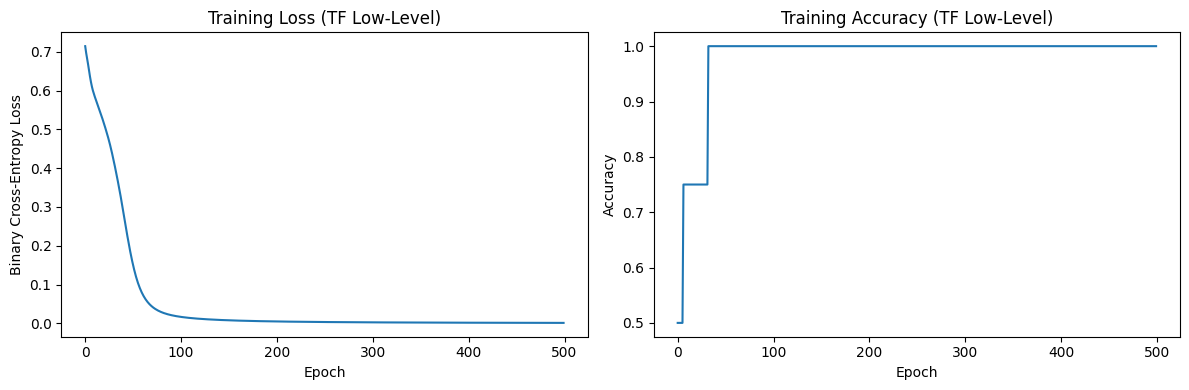

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(loss_history)
ax[0].set_title('Training Loss (TF Low-Level)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Binary Cross-Entropy Loss')

ax[1].plot(accuracy_history)
ax[1].set_title('Training Accuracy (TF Low-Level)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [ ]:
predictions_tf = mlp_forward(X_tf)

print("Input Combinations:\n", X_tf.numpy())
print("\nRaw Predictions (probabilities):\n", predictions_tf.numpy())
print("\nRounded Predictions:\n", tf.round(predictions_tf).numpy().astype(int))
print("\nActual XOR Outputs:\n", y_tf.numpy().astype(int))

correct = tf.reduce_sum(tf.cast(tf.equal(tf.round(predictions_tf), y_tf), tf.int32))
print(f"\nCorrect predictions: {correct.numpy()}/4")

Input Combinations:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Raw Predictions (probabilities):
 [[8.710448e-04]
 [9.984940e-01]
 [9.997922e-01]
 [1.670433e-03]]

Rounded Predictions:
 [[0]
 [1]
 [1]
 [0]]

Actual XOR Outputs:
 [[0]
 [1]
 [1]
 [0]]

Correct predictions: 4/4


Decision boundary plot for the TF low-level model

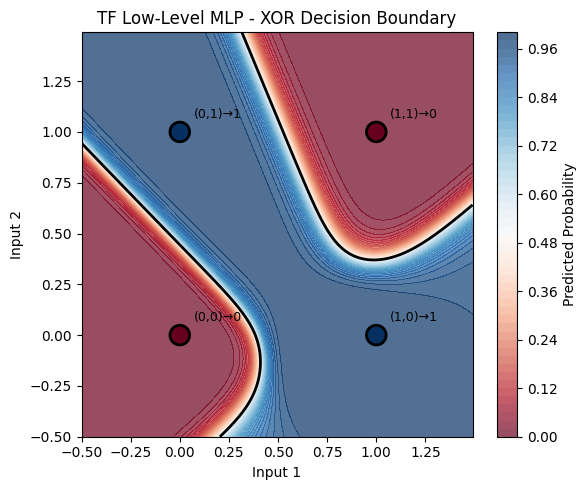

In [ ]:
def plot_decision_boundary_tf(forward_fn, X, y, title="Decision Boundary"):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                          np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = forward_fn(tf.constant(grid)).numpy()
    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, preds, levels=50, cmap='RdBu', alpha=0.7)
    plt.colorbar(label='Predicted Probability')
    plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=2)

    plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=y.numpy().ravel(), cmap='RdBu',
                edgecolors='black', s=200, linewidths=2)

    for i, (x0, x1) in enumerate(X.numpy()):
        plt.annotate(f'({int(x0)},{int(x1)})→{int(y.numpy()[i][0])}',
                      (x0, x1), textcoords="offset points",
                      xytext=(10, 10), fontsize=9)

    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_decision_boundary_tf(mlp_forward, X_tf, y_tf, title="TF Low-Level MLP - XOR Decision Boundary")

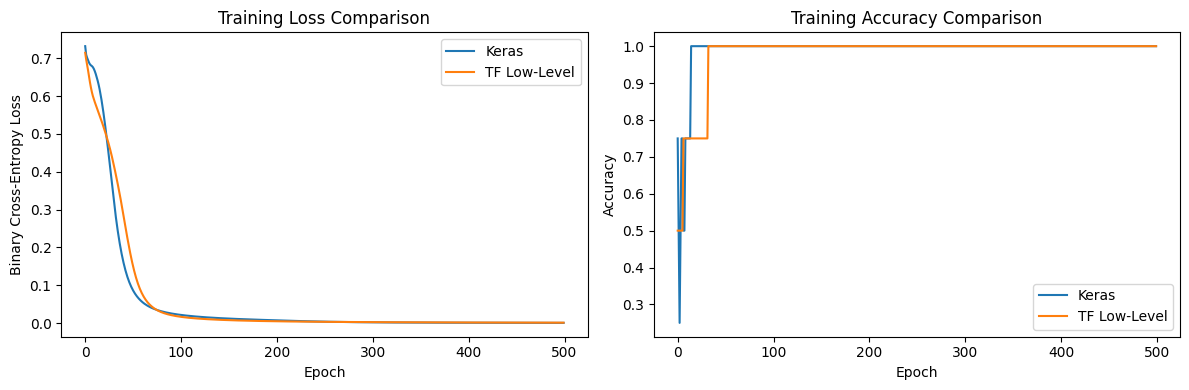

Keras       - Final Loss: 0.0005 | Final Accuracy: 1.0000
TF Low-Level - Final Loss: 0.0011 | Final Accuracy: 1.0000


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='Keras')
ax[0].plot(loss_history, label='TF Low-Level')
ax[0].set_title('Training Loss Comparison')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Binary Cross-Entropy Loss')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='Keras')
ax[1].plot(accuracy_history, label='TF Low-Level')
ax[1].set_title('Training Accuracy Comparison')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Keras       - Final Loss: {history.history['loss'][-1]:.4f} | Final Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"TF Low-Level - Final Loss: {loss_history[-1]:.4f} | Final Accuracy: {accuracy_history[-1]:.4f}")

In [ ]:

model_exp = Sequential([
    Dense(2, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_exp.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_exp = model_exp.fit(X, y, epochs=500, verbose=0)

print(f"Experiment 2 neurons, ReLU, lr=0.001 - Final Accuracy: {history_exp.history['accuracy'][-1]:.4f}")

Experiment 2 neurons, ReLU, lr=0.001 - Final Accuracy: 0.5000


In [ ]:
preds_exp = model_exp.predict(X, verbose=0)
print("Predictions:\n", preds_exp.round())
print("Actual:\n", y)

Predictions:
 [[1.]
 [1.]
 [0.]
 [0.]]
Actual:
 [[0.]
 [1.]
 [1.]
 [0.]]


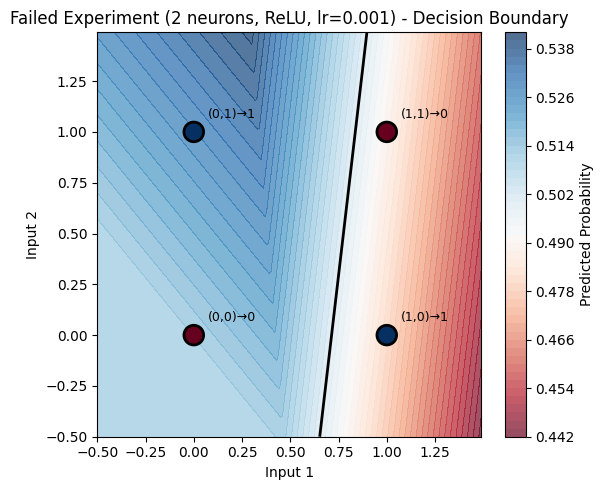

In [ ]:
plot_decision_boundary(model_exp, X, y, title="Failed Experiment (2 neurons, ReLU, lr=0.001) - Decision Boundary")

Learning rate

at 0.05 both models hit 100% accuracy in about 30-40 epochs at 0.001 training was still stuck after 500 epochs  with only four data points small steps barely move anything

Activation function     

Tanh with four neurons converged easily ReLU with two neurons got stuck on a straight line instead of the curve XOR needs since a dead ReLU neuron has no backup when there is only one other neuron to rely on

Neuron count followed the same pattern four neurons gave enough flexibility to bend the boundary correctly two neurons is the bare minimum so one bad neuron breaks the whole model

Epochs only help if the model is actually improving the four-neuron runs converged by epoch 40  so the rest was wasted the two-neuron ReLU run plateaued early and never moved again  more epochs couldn ot fix a model that was already stuck